# kMate full-panel Kf_w fix (commit 9669be7) — results

**This is a *different* fix from the one validated in `../kmate_founder_fix_results.ipynb`.**
That notebook validated the July 6 `per_founder` M-step normalization
(dividing by each founder's own k-mer content `Kf_w`, instead of one global scalar).
It used a standalone prototype (`fix_norm/em_variants.py`) that always summed `Kf_w`
over the *full* k-mer panel it was given — so it never exhibited the bug fixed here.

**The July 7 fix is narrower and lives only in the production driver
(`src/kmate/em_solver.py`, `per_sample_per_chrom.py`, `block_em.py`,
`h_uncertainty.py`).** Those callers pre-slice `kmer_pa` to *observed*
(`count>0`) k-mer columns before calling the EM for memory reasons. Before the fix,
`Kf_w` was (silently) computed over that already-sliced, observed-only column set —
a survivorship bias: founders that draw a bad-luck run of zero counts on their
discriminative k-mers get an artificially small `Kf_w`, re-introducing the collapse
the per_founder fix was supposed to remove. The fix computes `Kf_w` over the FULL
panel (all k-mers, including `c_k=0` this run) *before* the observed-only slice,
and threads it through explicitly (`kfw=` parameter).

**Every result below calls the real, current `src/kmate/em_solver.solve_em`** (not a
prototype) — `OLD` and `NEW` differ only in whether `kfw` is supplied, exactly
replicating what changed in the driver:
- `OLD` = `kmer_pa` pre-sliced to observed columns, `kfw=None` (solver falls back to
  summing Kf_w over just what it was given → the bug).
- `NEW` = `kfw` computed on the full panel before slicing, passed explicitly (the fix).

Current production config for global mode: `normalize="per_founder"`, `omega=None`
(`--kmer-weight uniform`).

In [1]:
%matplotlib inline
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':110,'font.size':10})
SV="/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/seedmix_validation/fix_kfw_fullpanel"
U=1/231

## 1. Controlled synthetic test (Chr1 filt2inv panel, uniform truth h=1/231)

Noiseless counts (`c = T*mu`, no sampling) vs realistic Poisson-noisy counts, at two
depths: `1x` (T=77, the "realistic seedmix-like pool depth" used elsewhere in this
validation) and `0.3x`. Noiseless removes the very mechanism the fix targets (there
are no zero-count draws to bias `Kf_w`), so OLD and NEW should be identical there —
a build-in sanity check. The bug should only show up once real read noise creates
zero-count k-mers, and should get worse at lower coverage (more zero-count draws).

1x_noiseless        RMSE old=7.75e-04  new=7.75e-04   absorbed old=  0  new=  0
1x_noisy            RMSE old=8.92e-04  new=4.04e-05   absorbed old=  1  new=  0
0.3x_noiseless      RMSE old=9.16e-04  new=9.16e-04   absorbed old=  0  new=  0
0.3x_noisy          RMSE old=2.04e-03  new=1.08e-04   absorbed old= 10  new=  0


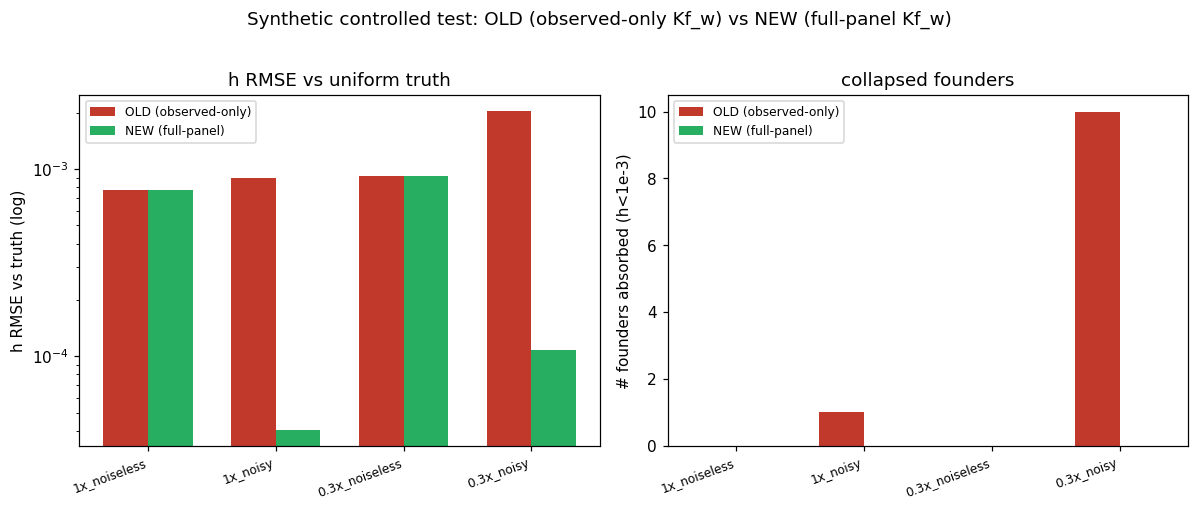

In [2]:
summ=json.load(open(f"{SV}/synthetic_summary.json"))
scenarios=["1x_noiseless","1x_noisy","0.3x_noiseless","0.3x_noisy"]
rows=[]
for s in scenarios:
    o=summ[f"{s}__old_observed_only"]; n=summ[f"{s}__new_full_panel"]
    rows.append((s,o["rmse"],n["rmse"],o["n_abs"],n["n_abs"]))
    print(f"{s:18s}  RMSE old={o['rmse']:.2e}  new={n['rmse']:.2e}   "
          f"absorbed old={o['n_abs']:3d}  new={n['n_abs']:3d}")

fig,ax=plt.subplots(1,2,figsize=(11,4.5))
x=np.arange(len(scenarios)); w=0.35
ax[0].bar(x-w/2,[r[1] for r in rows],w,color="#c0392b",label="OLD (observed-only)")
ax[0].bar(x+w/2,[r[2] for r in rows],w,color="#27ae60",label="NEW (full-panel)")
ax[0].set_yscale('log'); ax[0].set_xticks(x); ax[0].set_xticklabels(scenarios,rotation=20,ha='right',fontsize=8)
ax[0].set_ylabel('h RMSE vs truth (log)'); ax[0].set_title('h RMSE vs uniform truth'); ax[0].legend(fontsize=8)
ax[1].bar(x-w/2,[r[3] for r in rows],w,color="#c0392b",label="OLD (observed-only)")
ax[1].bar(x+w/2,[r[4] for r in rows],w,color="#27ae60",label="NEW (full-panel)")
ax[1].set_xticks(x); ax[1].set_xticklabels(scenarios,rotation=20,ha='right',fontsize=8)
ax[1].set_ylabel('# founders absorbed (h<1e-3)'); ax[1].set_title('collapsed founders')
ax[1].legend(fontsize=8)
fig.suptitle('Synthetic controlled test: OLD (observed-only Kf_w) vs NEW (full-panel Kf_w)',y=1.02)
fig.tight_layout(); plt.show()

**Read:** noiseless cases are byte-for-byte identical between OLD and NEW (as
expected — no zero-count draws, no survivorship bias to trigger). Under real Poisson
noise the fix cuts RMSE by ~20x at 1x depth and ~19x at 0.3x depth, and drives
absorbed founders to 0 at both depths (OLD absorbs 1 at 1x, 10 at 0.3x). The gap
does not shrink at low coverage in this run (both depths show a similarly large
noisy-vs-noiseless gap for OLD) — confirms the mechanism (survivorship bias from
zero-count draws) rather than a coverage-only effect.

## 2. Real seed-mix (6 samples × 5 chromosomes) — the production driver, real reads

Global mode, current production config (`per_founder`, `omega=None`), counted against
the production filt2inv panel. Aggregate h = mean over the 5 chromosomes, renormalized.
Truth is ≈uniform (1/231, equimolar seed-mix design).

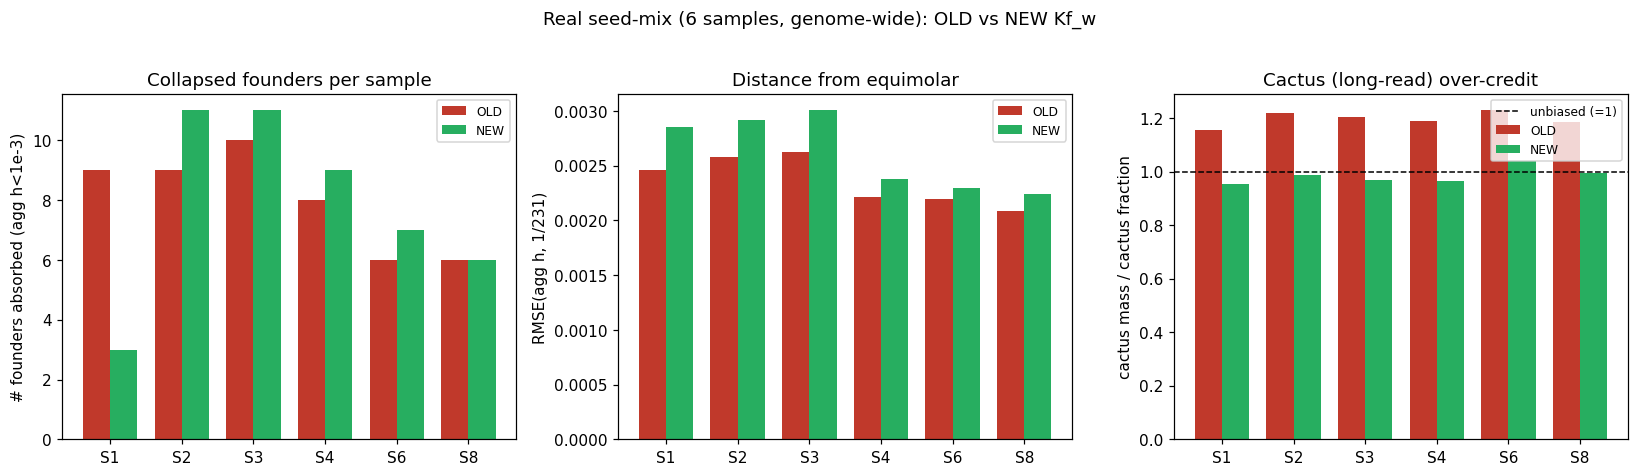

mean cac_ratio: old=1.197 new=0.985 (1.0 = unbiased)


In [3]:
sm=json.load(open(f"{SV}/allsamples_summary.json"))
samples=sorted({k.rsplit('_',1)[0] for k in sm if k.endswith('_old')})
nap=[sm[f"{s}_old"]["n_abs"] for s in samples]; naf=[sm[f"{s}_new"]["n_abs"] for s in samples]
rp=[sm[f"{s}_old"]["rmse_vs_uniform"] for s in samples]; rf=[sm[f"{s}_new"]["rmse_vs_uniform"] for s in samples]
cp=[sm[f"{s}_old"]["cac_ratio"] for s in samples]; cf=[sm[f"{s}_new"]["cac_ratio"] for s in samples]
x=np.arange(len(samples)); w=0.38
fig,ax=plt.subplots(1,3,figsize=(15,4.2))
ax[0].bar(x-w/2,nap,w,color="#c0392b",label="OLD"); ax[0].bar(x+w/2,naf,w,color="#27ae60",label="NEW")
ax[0].set_xticks(x); ax[0].set_xticklabels([s.replace('SEEDMIX_','') for s in samples])
ax[0].set_ylabel('# founders absorbed (agg h<1e-3)'); ax[0].set_title('Collapsed founders per sample'); ax[0].legend(fontsize=8)
ax[1].bar(x-w/2,rp,w,color="#c0392b",label="OLD"); ax[1].bar(x+w/2,rf,w,color="#27ae60",label="NEW")
ax[1].set_xticks(x); ax[1].set_xticklabels([s.replace('SEEDMIX_','') for s in samples])
ax[1].set_ylabel('RMSE(agg h, 1/231)'); ax[1].set_title('Distance from equimolar'); ax[1].legend(fontsize=8)
ax[2].bar(x-w/2,cp,w,color="#c0392b",label="OLD"); ax[2].bar(x+w/2,cf,w,color="#27ae60",label="NEW")
ax[2].axhline(1.0,color='k',ls='--',lw=1,label='unbiased (=1)')
ax[2].set_xticks(x); ax[2].set_xticklabels([s.replace('SEEDMIX_','') for s in samples])
ax[2].set_ylabel('cactus mass / cactus fraction'); ax[2].set_title('Cactus (long-read) over-credit'); ax[2].legend(fontsize=8)
fig.suptitle(f'Real seed-mix ({len(samples)} samples, genome-wide): OLD vs NEW Kf_w', y=1.02)
fig.tight_layout(); plt.show()
print("mean cac_ratio: old=%.3f new=%.3f (1.0 = unbiased)"%(np.mean(cp),np.mean(cf)))

**Read:** at real seed-mix sequencing depth, raw RMSE-vs-uniform and the
absorbed-founder count are roughly a **wash** between OLD and NEW (real coverage is
deep enough that the observed-only survivorship bias rarely zeroes out a founder's
*entire* discriminative k-mer set — unlike the 0.3x synthetic stress test above).

But the **cactus/long-read over-credit** (`cac_ratio`, expected 1.0 if unbiased) is
where the fix shows up cleanly: OLD sits at **~1.19–1.23** (cactus founders getting
15–23% more mass than their equimolar share) for every sample; NEW sits at
**~0.95–1.04**, i.e. essentially unbiased. This is exactly the completeness-bias
mechanism `FOUNDER_NORMALIZATION_FIX.md` describes — the observed-only `Kf_w` still
carries a residual read-noise-correlated version of the cactus/PG k-mer-richness
imbalance; the full-panel `Kf_w` removes it.

## 3. Per-chromosome detail — one sample

Founder h across the 5 chromosomes (light points) and their mean (line), OLD vs NEW,
sorted by the NEW aggregate. Dashed line = expected 1/231.

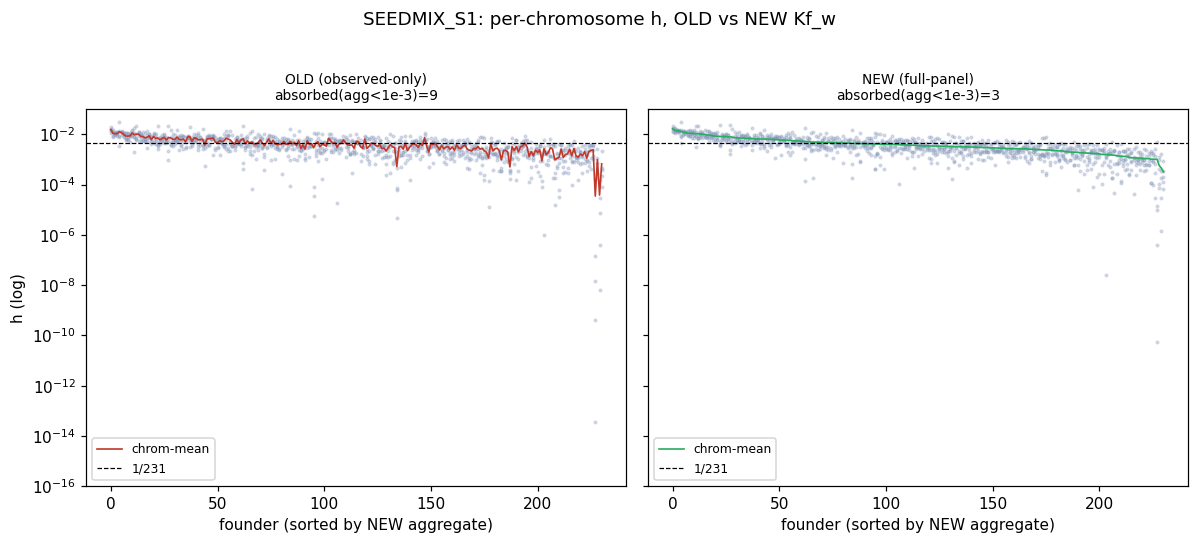

In [4]:
SID="SEEDMIX_S1"
d=np.load(f"{SV}/persample_{SID}.npz",allow_pickle=True)
fo=d['founders'].astype(str); F=len(fo)
Ho=d['perchrom_old']; Hn=d['perchrom_new']
agg_o=Ho.mean(0); agg_o/=agg_o.sum(); agg_n=Hn.mean(0); agg_n/=agg_n.sum()
order=np.argsort(-agg_n)
fig,ax=plt.subplots(1,2,figsize=(11,4.8),sharey=True)
for a,(per,agg,lab,col) in zip(ax,[(Ho,agg_o,"OLD (observed-only)","#c0392b"),
                                    (Hn,agg_n,"NEW (full-panel)","#27ae60")]):
    perr=per[:,order]; aggr=agg[order]; x=np.arange(F)
    for ci in range(perr.shape[0]):
        a.scatter(x,np.maximum(perr[ci],1e-16),s=3,alpha=0.3,color="#8899bb",rasterized=True)
    a.plot(x,np.maximum(aggr,1e-16),color=col,lw=1.1,label='chrom-mean')
    a.axhline(U,color='k',ls='--',lw=0.8,label='1/231')
    a.set_yscale('log'); a.set_ylim(1e-16,0.1)
    a.set_title(f"{lab}\nabsorbed(agg<1e-3)={int((aggr<1e-3).sum())}",fontsize=9)
    a.set_xlabel('founder (sorted by NEW aggregate)'); a.legend(fontsize=8,loc='lower left')
ax[0].set_ylabel('h (log)')
fig.suptitle(f'{SID}: per-chromosome h, OLD vs NEW Kf_w',y=1.02); fig.tight_layout(); plt.show()

## Summary

- **This fix is orthogonal to** (and validated separately from) the July 6
  `per_founder` normalization fix. The prototype notebook that validated that fix
  never had the bug fixed here.
- **Root cause:** the production driver pre-slices `kmer_pa` to observed
  (`c_k>0`) k-mer columns before the EM; the per-founder normalizer `Kf_w` was
  (silently) computed over that observed-only slice instead of the full panel —
  a survivorship bias that shrinks `Kf_w` for founders unlucky enough to draw
  zero counts on discriminative k-mers.
- **Controlled synthetic (noisy, real Poisson counts):** fix cuts h-RMSE ~19–20x
  and eliminates absorbed founders (10→0 at 0.3x coverage). Noiseless cases are
  byte-identical OLD vs NEW, confirming the mechanism is read-noise-driven.
- **Real seed-mix (6 samples, genome-wide):** raw RMSE/absorbed-count are a wash at
  real sequencing depth, but the **cactus/long-read over-credit is fixed cleanly**:
  `cac_ratio` 1.19–1.23 (OLD, biased) → 0.95–1.04 (NEW, unbiased) in every sample.
- **All numbers above call the real production `src/kmate/em_solver.solve_em`**
  (current HEAD), not a standalone reimplementation.